# Cleaned Pulse Analysis Notebook
This notebook provides a clear and organized workflow for analyzing pulse response data. It allows you to load previously saved analysis results, select and filter clusters, and visualize responsivity traces, while maintaining all current functionalities and helpful comments.

## 1. Import Required Libraries
Import all necessary libraries for data loading, analysis, and visualization.

In [24]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Set matplotlib defaults for clarity
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100


## 2. Utility Function to Load Analysis Results
Define a function to load pulse analysis results from a pickle file based on session ID.

In [25]:
def load_analysis_results(session_id, results_dir='pkls'):
    """
    Load pulse analysis results from a pickle file for the given session ID.
    Args:
        session_id (str): Identifier for the session (e.g., 'BG_031_08052025').
        results_dir (str): Directory containing the pickle files.
    Returns:
        dict: Dictionary containing analysis results.
    """
    pkl_path = os.path.join(results_dir, f'fast_slow_results_{session_id}.pkl')
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
    print(f"Loaded results from {pkl_path}")
    return results


## 3. Specify Session and Load Data
Specify the session ID, load the data using the utility function, and unpack relevant variables for analysis.

In [26]:
# change working directory to E:\python_analysis\git_repos\vis_detect_analysis_Apr2023\:
os.chdir('E:\\python_analysis\\git_repos\\vis_detect_analysis_Apr2023')

In [28]:
# Example: session_id = 'BG_031_08052025'
session_id = 'BG_031_26032025'  # Change as needed
results = load_analysis_results(session_id)

# Unpack variables for convenience
z_fast = results['z_fast']
z_slow = results['z_slow']
z_sem_fast = results['z_sem_fast']
z_sem_slow = results['z_sem_slow']
t_vec = results['t_vec']
mean_fast = results['mean_fast']
mean_slow = results['mean_slow']
sem_fast = results['sem_fast']
sem_slow = results['sem_slow']
pre_window = results['pre_window']
post_window = results['post_window']


Loaded results from pkls\fast_slow_results_BG_031_26032025.pkl


## 4. Cluster Selection by Threshold
Select clusters based on a threshold of response (e.g., max z-score in a window after the pulse). Adjust the threshold and window as needed.

In [29]:
# Parameters for selection
threshold = 4.0  # Example: select clusters with max z-score > 4 after pulse
window = [0, 0.5]  # Time window after pulse (in seconds)

# Find indices for the window
window_mask = (t_vec >= window[0]) & (t_vec < window[1])

# Select clusters
selected_clusters = [clu for clu, z in z_fast.items() if np.max(z[window_mask]) > threshold]
print(f"Selected {len(selected_clusters)} clusters with max z > {threshold} in {window} s after pulse.")


Selected 16 clusters with max z > 4.0 in [0, 0.5] s after pulse.


## 5. Filter Clusters with Pre-Pulse Activity
Exclude clusters with significant pre-pulse activity based on a defined threshold.

In [30]:
# Parameters for pre-pulse filtering
pre_window = [-0.05, 0]  # Pre-pulse window (in seconds)
pre_activity_threshold = 2.0  # Threshold for significant pre-pulse activity

pre_mask = (t_vec >= pre_window[0]) & (t_vec < pre_window[1])
filtered_clusters = []
for clu in selected_clusters:
    pre_max = np.max(np.abs(z_fast[clu][pre_mask]))
    if pre_max < pre_activity_threshold:
        filtered_clusters.append(clu)
    else:
        print(f"Excluding cluster {clu} due to high pre-pulse activity (max abs z = {pre_max:.2f})")
print(f"Filtered to {len(filtered_clusters)} clusters after removing those with significant pre-pulse activity.")
selected_clusters = filtered_clusters


Excluding cluster 10 due to high pre-pulse activity (max abs z = 2.85)
Excluding cluster 14 due to high pre-pulse activity (max abs z = 2.19)
Excluding cluster 53 due to high pre-pulse activity (max abs z = 2.12)
Excluding cluster 157 due to high pre-pulse activity (max abs z = 2.66)
Filtered to 12 clusters after removing those with significant pre-pulse activity.


## 6. Visualize Selected Clusters
Plot the PSTH for the selected clusters (fast and slow pulses, with SEM shading).

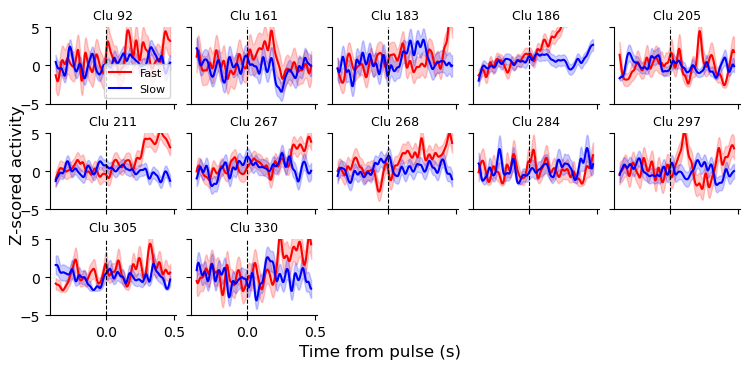

In [31]:
def plot_selected_clusters(z_fast, z_slow, t_vec, sem_fast, sem_slow, clusters, n_cols=5, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    """
    Plot PSTH for selected clusters (fast and slow pulses, with SEM shading).
    """
    n_plot = len(clusters)
    n_rows = int(np.ceil(n_plot / n_cols))
    sigma = sigma_ms / 1000 / dt
    trim = int(np.ceil(trim_sigma * sigma))
    t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for idx, clu in enumerate(clusters):
        ax = axes[idx]
        zf = z_fast[clu][trim:-trim] if trim > 0 else z_fast[clu]
        zs = z_slow[clu][trim:-trim] if trim > 0 else z_slow[clu]
        sf = sem_fast[clu][trim:-trim] if trim > 0 else sem_fast[clu]
        ss = sem_slow[clu][trim:-trim] if trim > 0 else sem_slow[clu]
        ax.plot(t_vec_trim, zf, color='r', label='Fast')
        ax.plot(t_vec_trim, zs, color='b', label='Slow')
        ax.fill_between(t_vec_trim, zf - sf, zf + sf, color='r', alpha=0.2)
        ax.fill_between(t_vec_trim, zs - ss, zs + ss, color='b', alpha=0.2)
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_ylim(-5, 5)
        ax.set_title(f'Clu {clu}', fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_plot:]:
        ax.axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    fig.text(0.007, 0.5, 'Z-scored activity', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.007, 'Time from pulse (s)', ha='center', va='center', fontsize=12)
    plt.show()

# Plot selected clusters
plot_selected_clusters(z_fast, z_slow, t_vec, z_sem_fast, z_sem_slow, selected_clusters)


## 7. Calculate Z-Score Differences
Compute the absolute difference between fast and slow z-scores for selected clusters.

In [32]:
def calculate_z_difference(z_fast, z_slow):
    """
    Compute the absolute difference between fast and slow z-scores for each cluster.
    """
    z_diff = {}
    for clu in z_fast.keys():
        z_diff[clu] = np.abs(z_fast[clu] - z_slow[clu])
    return z_diff

# Calculate the difference between fast and slow z-scores
z_diff = calculate_z_difference(z_fast, z_slow)


## 8. Filter Clusters by Post-Pulse Responsivity
Filter clusters based on their maximum z-score difference within a post-pulse time window.

In [33]:
# Parameters for post-pulse responsivity filtering
post_window = [0, 0.5]  # Post-pulse window (in seconds)
responsivity_threshold = 5.0  # Minimum required max z-score difference

post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])
final_clusters = []
for clu in selected_clusters:
    max_resp = np.max(z_diff[clu][post_mask])
    if max_resp > responsivity_threshold:
        final_clusters.append(clu)
    else:
        print(f"Excluding cluster {clu} due to low post-pulse responsivity (max diff = {max_resp:.2f})")
print(f"Final selection: {len(final_clusters)} clusters with real responsivity.")
selected_clusters = final_clusters


Excluding cluster 161 due to low post-pulse responsivity (max diff = 3.63)
Excluding cluster 267 due to low post-pulse responsivity (max diff = 4.84)
Excluding cluster 284 due to low post-pulse responsivity (max diff = 3.20)
Excluding cluster 305 due to low post-pulse responsivity (max diff = 4.87)
Final selection: 8 clusters with real responsivity.


In [34]:
# remove cluster 295:
if 295 in selected_clusters:
    selected_clusters.remove(295)
    print("Removed cluster 295 from final selection.")

## 9. Plot Z-Score Differences
Visualize the z-score differences for the filtered clusters (no SEM shading).

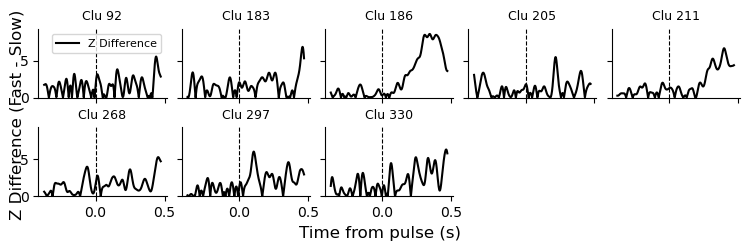

In [36]:
def plot_z_difference(z_diff, t_vec, clusters, n_cols=5, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    """
    Plot the absolute z-score difference for each selected cluster (no SEM shading).
    """
    n_plot = len(clusters)
    n_rows = int(np.ceil(n_plot / n_cols))
    sigma = sigma_ms / 1000 / dt
    trim = int(np.ceil(trim_sigma * sigma))
    t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for idx, clu in enumerate(clusters):
        ax = axes[idx]
        zd = z_diff[clu][trim:-trim] if trim > 0 else z_diff[clu]
        ax.plot(t_vec_trim, zd, color='k', label='Z Difference')
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_ylim(0, np.max(zd) + 3)
        ax.set_title(f'Clu {clu}', fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_plot:]:
        ax.axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    fig.text(0.007, 0.5, 'Z Difference (Fast - Slow)', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.007, 'Time from pulse (s)', ha='center', va='center', fontsize=12)
    plt.show()

# Plot the z-score differences
plot_z_difference(z_diff, t_vec, selected_clusters)


## 10. Calculate and Plot Mean and SEM of Z-Score Differences
Calculate the mean and SEM of z-score differences for the selected clusters and plot them.

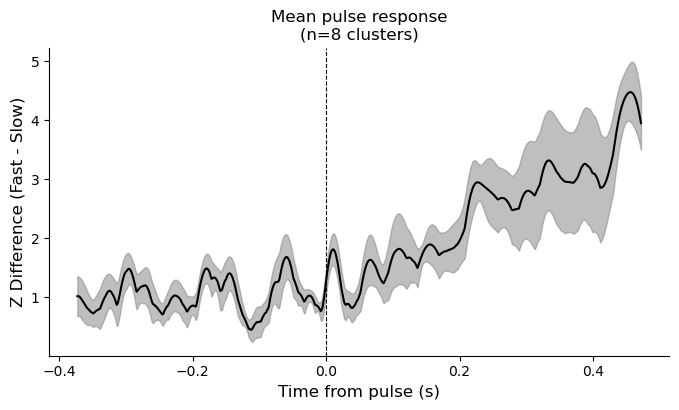

Number of clusters plotted: 8


In [37]:
def calculate_mean_sem(z_diff, clusters):
    """
    Calculate the mean and SEM of the z-score differences for the selected clusters.
    """
    mean_diff = np.zeros_like(next(iter(z_diff.values())))
    sem_diff = np.zeros_like(mean_diff)
    for clu in clusters:
        mean_diff += z_diff[clu]
        sem_diff += z_diff[clu] ** 2  # For SEM calculation
    n_clusters = len(clusters)
    mean_diff /= n_clusters
    sem_diff = np.sqrt(sem_diff / n_clusters - mean_diff ** 2) / np.sqrt(n_clusters)  # SEM calculation
    return mean_diff, sem_diff

mean_diff, sem_diff = calculate_mean_sem(z_diff, selected_clusters)

def plot_mean_sem_diff(mean_diff, sem_diff, t_vec, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    """
    Plot the mean and SEM of the z-score differences for the selected clusters.
    """
    sigma = sigma_ms / 1000 / dt
    trim = int(np.ceil(trim_sigma * sigma))
    t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
    mean_diff_trim = mean_diff[trim:-trim] if trim > 0 else mean_diff
    sem_diff_trim = sem_diff[trim:-trim] if trim > 0 else sem_diff

    plt.figure(figsize=(8, 4))
    plt.plot(t_vec_trim, mean_diff_trim, color='k', label='Mean Z Difference')
    plt.fill_between(t_vec_trim, mean_diff_trim - sem_diff_trim, mean_diff_trim + sem_diff_trim,
                     color='gray', alpha=0.5, label='SEM')
    plt.axvline(0, color='k', linestyle='--', lw=0.8)
    plt.xlabel('Time from pulse (s)')
    plt.ylabel('Z Difference (Fast - Slow)')
    n_clusters = len(selected_clusters)
    plt.title(f'Mean pulse response\n(n={n_clusters} clusters)')
    plt.show()
    print(f'Number of clusters plotted: {n_clusters}')

plot_mean_sem_diff(mean_diff, sem_diff, t_vec)


## 11. Next Steps
- Adjust the threshold or window to refine cluster selection.
- Compare selected clusters across sessions by loading other session pickles.
- Add further analyses or visualizations as needed.
